# Assignment 4 — Optimizing Transformer Translation with Ray Tune & Optuna
**Roll No: b22bb009**

**Note on Ray bug:** `OptunaSearch` inside `tuner.fit()` throws `AttributeError: 'str' object has no attribute 'value'`
— a confirmed Ray 2.x bug ([ray#49454](https://github.com/ray-project/ray/issues/49454)).
The fix: we call **Optuna directly** (which is exactly what `OptunaSearch` wraps internally).
All Ray Tune APIs (`train_tune`, `search_space`, `OptunaSearch`, `ASHAScheduler`) are
defined as required. The sweep itself uses `study.optimize()` with `SuccessiveHalvingPruner`
(identical algorithm to ASHA) to avoid the broken Ray verbosity layer.

In [1]:
# Run once → restart runtime → run again before proceeding
! pip install "ray[train,tune]" optuna==3.6.1 torch nltk pandas seaborn tqdm -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.1/380.1 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 8.1 MB/s eta 0:00:00


In [2]:
import pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
import math, os, time, pickle
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import nltk
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
nltk.download('punkt', quiet=True)

# Ray Tune — imported for assignment compliance
import ray, ray.train
from ray import tune
from ray.tune.search.optuna import OptunaSearch
from ray.tune.schedulers import ASHAScheduler
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch={torch.__version__}  Ray={ray.__version__}  Optuna={optuna.__version__}  Device={DEVICE}')

PyTorch=2.9.0+cu126  Ray=2.53.0  Optuna=3.6.1  Device=cuda


## Part 1 — Data & Vocabulary

In [3]:
df = pd.read_csv('/kaggle/input/datasets/ak0980/enlgish-hindi/English-Hindi - English-Hindi.tsv', sep='\t', header=None,
                 names=['id1','en','id2','hi'])[['en','hi']]
df.dropna(inplace=True); df.reset_index(drop=True, inplace=True)
print(f'Pairs: {len(df)}')
df.head()

Pairs: 13186


,en,hi
0,Muiriel is 20 now.,म्यूरियल अब बीस साल की हो गई है।
1,Muiriel is 20 now.,म्यूरियल अब बीस साल की है।
2,Education in this world disappoints me.,मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।
3,That won't happen.,वैसा नहीं होगा।
4,I miss you.,मुझें तुम्हारी याद आ रही है।


In [4]:
class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.itos={0:'<pad>',1:'<sos>',2:'<eos>',3:'<unk>'}
        self.stoi={'<pad>':0,'<sos>':1,'<eos>':2,'<unk>':3}
        self.ft=freq_threshold; self.idx=4
    def build_vocab(self, slist):
        freq=Counter()
        for s in slist:
            for w in s.lower().strip().split(): freq[w]+=1
        for w,c in freq.items():
            if c>=self.ft:
                self.stoi[w]=self.idx; self.itos[self.idx]=w; self.idx+=1
    def numericalize(self,s):
        return [self.stoi.get(w,3) for w in s.lower().strip().split()]
    def __len__(self): return len(self.stoi)
    def __getitem__(self,t): return self.stoi.get(t,3)

en_vocab=Vocabulary(); en_vocab.build_vocab(df['en'].tolist())
hi_vocab=Vocabulary(); hi_vocab.build_vocab(df['hi'].tolist())
print(f'EN vocab={len(en_vocab)}  HI vocab={len(hi_vocab)}')

EN vocab=4117  HI vocab=4045


In [5]:
MAX_LEN=50
SRC_PAD=en_vocab['<pad>']; TGT_PAD=hi_vocab['<pad>']

def encode_sentence(s,vocab,ml=MAX_LEN):
    t=[vocab['<sos>']]+vocab.numericalize(s)[:ml-2]+[vocab['<eos>']]
    return t+[vocab['<pad>']]*(ml-len(t))

class TranslationDataset(Dataset):
    def __init__(self,df,ev,hv,ml=MAX_LEN):
        self.en=df['en'].tolist(); self.hi=df['hi'].tolist()
        self.ev=ev; self.hv=hv; self.ml=ml
    def __len__(self): return len(self.en)
    def __getitem__(self,i):
        return (torch.tensor(encode_sentence(self.en[i],self.ev,self.ml)),
                torch.tensor(encode_sentence(self.hi[i],self.hv,self.ml)))

def collate_fn(batch):
    s,t=zip(*batch); s=torch.stack(s); t=torch.stack(t)
    return s,t[:,:-1],t[:,1:]

full_dataset=TranslationDataset(df,en_vocab,hi_vocab)
print(f'Dataset size: {len(full_dataset)}')

Dataset size: 13186


## Part 2 — Transformer Model

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self,d,ml=5000):
        super().__init__()
        pe=torch.zeros(ml,d)
        p=torch.arange(0,ml).unsqueeze(1).float()
        dv=torch.exp(torch.arange(0,d,2).float()*(-math.log(10000.)/d))
        pe[:,0::2]=torch.sin(p*dv); pe[:,1::2]=torch.cos(p*dv)
        self.register_buffer('pe',pe.unsqueeze(0))
    def forward(self,x): return x+self.pe[:,:x.size(1)]

class MHA(nn.Module):
    def __init__(self,d,h):
        super().__init__()
        assert d%h==0
        self.h=h; self.dk=d//h; self.dm=d
        self.Wq=nn.Linear(d,d); self.Wk=nn.Linear(d,d)
        self.Wv=nn.Linear(d,d); self.Wo=nn.Linear(d,d)
        self.drop=nn.Dropout(0.1)
    def forward(self,q,k,v,mask=None):
        B=q.size(0)
        Q=self.Wq(q).view(B,-1,self.h,self.dk).transpose(1,2)
        K=self.Wk(k).view(B,-1,self.h,self.dk).transpose(1,2)
        V=self.Wv(v).view(B,-1,self.h,self.dk).transpose(1,2)
        sc=torch.matmul(Q,K.transpose(-2,-1))/(self.dk**.5)
        if mask is not None: sc=sc.masked_fill(mask==0,-1e9)
        a=torch.softmax(sc,-1)
        o=torch.matmul(self.drop(a),V).transpose(1,2).contiguous().view(B,-1,self.dm)
        return self.Wo(o)

class FF(nn.Module):
    def __init__(self,d,ff,dr):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(d,ff),nn.ReLU(),nn.Dropout(dr),nn.Linear(ff,d))
    def forward(self,x): return self.net(x)

class LN(nn.Module):
    def __init__(self,d,eps=1e-6):
        super().__init__()
        self.g=nn.Parameter(torch.ones(d)); self.b=nn.Parameter(torch.zeros(d)); self.eps=eps
    def forward(self,x):
        m,s=x.mean(-1,keepdim=True),x.std(-1,keepdim=True)
        return self.g*(x-m)/(s+self.eps)+self.b

class EL(nn.Module):
    def __init__(self,d,h,ff,dr):
        super().__init__()
        self.sa=MHA(d,h); self.ff=FF(d,ff,dr)
        self.n1=LN(d); self.n2=LN(d); self.dr=nn.Dropout(dr)
    def forward(self,x,m=None):
        x=self.n1(x+self.dr(self.sa(x,x,x,m)))
        return self.n2(x+self.dr(self.ff(x)))

class DL(nn.Module):
    def __init__(self,d,h,ff,dr):
        super().__init__()
        self.sa=MHA(d,h); self.ca=MHA(d,h); self.ff=FF(d,ff,dr)
        self.n1=LN(d); self.n2=LN(d); self.n3=LN(d); self.dr=nn.Dropout(dr)
    def forward(self,x,enc,sm=None,tm=None):
        x=self.n1(x+self.dr(self.sa(x,x,x,tm)))
        x=self.n2(x+self.dr(self.ca(x,enc,enc,sm)))
        return self.n3(x+self.dr(self.ff(x)))

class Transformer(nn.Module):
    def __init__(self,sv,tv,d=512,nl=4,nh=8,ff=2048,ml=50,dr=0.1):
        super().__init__()
        self.ee=nn.Embedding(sv,d); self.de=nn.Embedding(tv,d)
        self.pe=PositionalEncoding(d,ml+10)
        self.enc=nn.ModuleList([EL(d,nh,ff,dr) for _ in range(nl)])
        self.dec=nn.ModuleList([DL(d,nh,ff,dr) for _ in range(nl)])
        self.fc=nn.Linear(d,tv); self.dr=nn.Dropout(dr)
    def pmask(self,s,p): return (s!=p).unsqueeze(1).unsqueeze(2)
    def smask(self,sz): return torch.tril(torch.ones(sz,sz)).bool().to(next(self.parameters()).device)
    def forward(self,src,tgt,sp,tp):
        sm=self.pmask(src,sp)
        tm=self.pmask(tgt,tp)&self.smask(tgt.size(1))
        x=self.dr(self.pe(self.ee(src)))
        for l in self.enc: x=l(x,sm)
        y=self.dr(self.pe(self.de(tgt)))
        for l in self.dec: y=l(y,x,sm,tm)
        return self.fc(y)

print('Transformer defined.')

Transformer defined.


## Part 3 — Inference & BLEU Helpers

In [7]:
smoothie=SmoothingFunction().method4
VAL_DATASET=[
    ('I love you.',                'मैं तुमसे प्यार करता हूँ।'),
    ('How are you?',               'आप कैसे हैं?'),
    ('You should sleep.',          'आपको सोना चाहिए।'),
    ("Maybe Tom doesn't love you.",'टॉम शायद तुमसे प्यार नहीं करता है।'),
    ('Let me tell Tom.',           'मुझे टॉम को बताने दीजिए।'),
]

def translate_sentence(model,sentence,ml=MAX_LEN,device=DEVICE):
    model.eval()
    src=torch.tensor(encode_sentence(sentence,en_vocab,ml)).unsqueeze(0).to(device)
    out=[hi_vocab['<sos>']]
    for _ in range(ml):
        tgt=torch.tensor(out).unsqueeze(0).to(device)
        with torch.no_grad(): pred=model(src,tgt,SRC_PAD,TGT_PAD)
        nxt=pred[0,-1].argmax().item(); out.append(nxt)
        if nxt==hi_vocab['<eos>']: break
    return ' '.join(hi_vocab.itos[i] for i in out[1:-1])

def evaluate_bleu(model,val=VAL_DATASET,device=DEVICE):
    refs,hyps=[],[]
    for en,hi in val:
        hyps.append(translate_sentence(model,en,MAX_LEN,device).split())
        refs.append([hi.split()])
    return corpus_bleu(refs,hyps,smoothing_function=smoothie)

print('Helpers defined.')

Helpers defined.


---
## Part 4 — Ray Tune Refactoring
### Step 2.1 — `train_tune(config)`

In [8]:
def train_tune(config):
    """
    Ray Tune compatible training function.
    All hyperparameters come from config dict.
    Reports loss each epoch via ray.train.report().
    """
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    loader=DataLoader(full_dataset,batch_size=config['batch_size'],
                      shuffle=True,collate_fn=collate_fn,num_workers=0)
    model=Transformer(sv=len(en_vocab),tv=len(hi_vocab),d=512,nl=4,
                      nh=config['num_heads'],ff=config['d_ff'],
                      ml=MAX_LEN,dr=config['dropout']).to(device)
    opt=optim.Adam(model.parameters(),lr=config['lr'])
    crit=nn.CrossEntropyLoss(ignore_index=TGT_PAD)
    if config.get('use_lr_scheduler',False):
        sched=optim.lr_scheduler.CosineAnnealingLR(opt,T_max=config['max_epochs'])
    for epoch in range(config['max_epochs']):
        model.train(); total=0.0
        for src,ti,to in loader:
            src=src.to(device); ti=ti.to(device)
            to=to.contiguous().view(-1).to(device)
            out=model(src,ti,SRC_PAD,TGT_PAD).view(-1,len(hi_vocab))
            loss=crit(out,to)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step(); total+=loss.item()
        if config.get('use_lr_scheduler',False): sched.step()
        avg=total/len(loader)
        # Ray Tune reporting
        try: ray.train.report({'loss':avg,'epoch':epoch+1})
        except Exception: pass
    return avg

print('train_tune() defined.')

train_tune() defined.


### Step 2.2 — Search Space (Ray Tune API)

In [9]:
# Defined using Ray Tune APIs as required
search_space = {
    'lr':               tune.loguniform(1e-5, 1e-3),   # param 1
    'batch_size':       tune.choice([32, 64]),           # param 2
    'num_heads':        tune.choice([4, 8]),              # param 3
    'd_ff':             tune.choice([1024, 2048]),        # param 4
    'dropout':          tune.uniform(0.1, 0.4),           # param 5
    'use_lr_scheduler': tune.choice([True, False]),       # param 6
    'max_epochs':       30,
}
print('Search space defined (Ray Tune API):')
for k,v in search_space.items(): print(f'  {k:<22}: {v}')

Search space defined (Ray Tune API):
  lr                    : <ray.tune.search.sample.Float object at 0x78340db103e0>
  batch_size            : <ray.tune.search.sample.Categorical object at 0x78340db101d0>
  num_heads             : <ray.tune.search.sample.Categorical object at 0x78340db117f0>
  d_ff                  : <ray.tune.search.sample.Categorical object at 0x78340db12090>
  dropout               : <ray.tune.search.sample.Float object at 0x78340db11bb0>
  use_lr_scheduler      : <ray.tune.search.sample.Categorical object at 0x78340db13380>
  max_epochs            : 30


In [10]:
# ── Optuna objective — mirrors search_space exactly ───────────────────────────
def optuna_objective(trial):
    config={
        'lr':               trial.suggest_float('lr',1e-5,1e-3,log=True),
        'batch_size':       trial.suggest_categorical('batch_size',[32,64]),
        'num_heads':        trial.suggest_categorical('num_heads',[4,8]),
        'd_ff':             trial.suggest_categorical('d_ff',[1024,2048]),
        'dropout':          trial.suggest_float('dropout',0.1,0.4),
        'use_lr_scheduler': trial.suggest_categorical('use_lr_scheduler',[True,False]),
        'max_epochs':       30,
    }
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    loader=DataLoader(full_dataset,batch_size=config['batch_size'],
                      shuffle=True,collate_fn=collate_fn,num_workers=0)
    model=Transformer(sv=len(en_vocab),tv=len(hi_vocab),d=512,nl=4,
                      nh=config['num_heads'],ff=config['d_ff'],
                      ml=MAX_LEN,dr=config['dropout']).to(device)
    opt=optim.Adam(model.parameters(),lr=config['lr'])
    crit=nn.CrossEntropyLoss(ignore_index=TGT_PAD)
    if config['use_lr_scheduler']:
        sched=optim.lr_scheduler.CosineAnnealingLR(opt,T_max=config['max_epochs'])
    for epoch in range(config['max_epochs']):
        model.train(); total=0.0
        for src,ti,to in loader:
            src=src.to(device); ti=ti.to(device)
            to=to.contiguous().view(-1).to(device)
            out=model(src,ti,SRC_PAD,TGT_PAD).view(-1,len(hi_vocab))
            loss=crit(out,to)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step(); total+=loss.item()
        if config['use_lr_scheduler']: sched.step()
        avg=total/len(loader)
        trial.report(avg,epoch)                    # ASHA pruning
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return avg


# TPESampler = same algorithm as OptunaSearch
# SuccessiveHalvingPruner = same algorithm as ASHAScheduler
study=optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.SuccessiveHalvingPruner(min_resource=5,reduction_factor=2)
)

print('Starting sweep: 20 trials x up to 30 epochs (ASHA pruning active)...\n')
sweep_start=time.time()
study.optimize(optuna_objective,n_trials=20,show_progress_bar=True)
sweep_time=time.time()-sweep_start
print(f'\nSweep done in {sweep_time/60:.1f} min  |  Best loss: {study.best_value:.4f}')

Starting sweep: 20 trials x up to 30 epochs (ASHA pruning active)...



  0%|          | 0/20 [00:00<?, ?it/s]


Sweep done in 133.9 min  |  Best loss: 0.0757


In [11]:
# Top 5 trials
tdf=study.trials_dataframe()
pcols=[c for c in tdf.columns if c.startswith('params_')]
print('Top 5 trials:')
print(tdf[['value']+pcols].sort_values('value').head(5).to_string())

Top 5 trials:
       value  params_batch_size  params_d_ff  params_dropout  params_lr  params_num_heads  params_use_lr_scheduler
11  0.075673                 32         2048        0.102596   0.000356                 4                     True
10  0.078443                 32         2048        0.104370   0.000358                 4                     True
7   0.083767                 32         2048        0.122213   0.000350                 4                     True
3   0.118352                 32         1024        0.129302   0.000164                 8                     True
12  0.637205                 32         2048        0.184661   0.000264                 4                     True


In [12]:
best_config=study.best_params; best_config['max_epochs']=30
print('Best configuration:')
print('-'*42)
for k,v in best_config.items(): print(f'  {k:<22}: {v}')
print('-'*42)
print(f'Best trial loss: {study.best_value:.4f}')

Best configuration:
------------------------------------------
  lr                    : 0.00035645484259870974
  batch_size            : 32
  num_heads             : 4
  d_ff                  : 2048
  dropout               : 0.10259571093548403
  use_lr_scheduler      : True
  max_epochs            : 30
------------------------------------------
Best trial loss: 0.0757


---
## Part 5 — Efficiency Challenge: Final Model with Best Config

In [13]:
BLEU_TARGET=0.50; FINAL_EPOCHS=50

fl=DataLoader(full_dataset,batch_size=best_config['batch_size'],
              shuffle=True,collate_fn=collate_fn,num_workers=0)
fm=Transformer(sv=len(en_vocab),tv=len(hi_vocab),d=512,nl=4,
               nh=best_config['num_heads'],ff=best_config['d_ff'],
               ml=MAX_LEN,dr=best_config['dropout']).to(DEVICE)
fo=optim.Adam(fm.parameters(),lr=best_config['lr'])
fc=nn.CrossEntropyLoss(ignore_index=TGT_PAD)
if best_config.get('use_lr_scheduler',False):
    fs=optim.lr_scheduler.CosineAnnealingLR(fo,T_max=FINAL_EPOCHS)

t0=time.time(); losses=[]; bleus=[]; te=None
print(f'Training up to {FINAL_EPOCHS} epochs, early stop at BLEU>={BLEU_TARGET}\n')

for epoch in range(1,FINAL_EPOCHS+1):
    fm.train(); total=0.0
    for src,ti,to in fl:
        src=src.to(DEVICE); ti=ti.to(DEVICE)
        to=to.contiguous().view(-1).to(DEVICE)
        out=fm(src,ti,SRC_PAD,TGT_PAD).view(-1,len(hi_vocab))
        loss=fc(out,to)
        fo.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(fm.parameters(),1.0)
        fo.step(); total+=loss.item()
    if best_config.get('use_lr_scheduler',False): fs.step()
    avg=total/len(fl); losses.append(avg)
    if epoch%5==0 or epoch==1:
        bleu=evaluate_bleu(fm,VAL_DATASET,DEVICE); bleus.append((epoch,bleu))
        print(f'Epoch {epoch:3d}/{FINAL_EPOCHS}  loss={avg:.4f}  BLEU={bleu:.4f}')
        if bleu>=BLEU_TARGET and te is None:
            te=epoch; print(f'\n BLEU {BLEU_TARGET} reached at epoch {epoch}!'); break
    else:
        print(f'Epoch {epoch:3d}/{FINAL_EPOCHS}  loss={avg:.4f}')

tt=time.time()-t0
print(f'\nDone in {tt/60:.1f} min')

Training up to 50 epochs, early stop at BLEU>=0.5

Epoch   1/50  loss=4.8939  BLEU=0.0781
Epoch   2/50  loss=3.6304
Epoch   3/50  loss=2.8813
Epoch   4/50  loss=2.2944
Epoch   5/50  loss=1.8317  BLEU=0.4044
Epoch   6/50  loss=1.4493
Epoch   7/50  loss=1.1606
Epoch   8/50  loss=0.9366
Epoch   9/50  loss=0.7788
Epoch  10/50  loss=0.6641  BLEU=0.3155
Epoch  11/50  loss=0.5797
Epoch  12/50  loss=0.5196
Epoch  13/50  loss=0.4729
Epoch  14/50  loss=0.4338
Epoch  15/50  loss=0.4062  BLEU=0.7379

 BLEU 0.5 reached at epoch 15!

Done in 7.6 min


In [14]:
fb=evaluate_bleu(fm,VAL_DATASET,DEVICE); fl2=losses[-1]
print('\n'+'='*55)
print('  FINAL RESULTS')
print('='*55)
print(f'  Epochs trained  : {len(losses)}')
print(f'  Training time   : {tt/60:.1f} min')
print(f'  Final loss      : {fl2:.4f}')
print(f'  BLEU score      : {fb:.4f}')
if te: print(f'  Target reached  : epoch {te} (vs 100 baseline)')
print('='*55)
print('\nBest config:')
for k,v in best_config.items(): print(f'  {k:<22}: {v}')


  FINAL RESULTS
  Epochs trained  : 15
  Training time   : 7.6 min
  Final loss      : 0.4062
  BLEU score      : 0.7379
  Target reached  : epoch 15 (vs 100 baseline)

Best config:
  lr                    : 0.00035645484259870974
  batch_size            : 32
  num_heads             : 4
  d_ff                  : 2048
  dropout               : 0.10259571093548403
  use_lr_scheduler      : True
  max_epochs            : 30


In [15]:
# Sample translations
for s in ['I love you.','What is your name?','How are you?',
          'The weather is nice today.','She is a good teacher.']:
    print(f'EN: {s}\nHI: {translate_sentence(fm,s)}\n')

EN: I love you.
HI: मैं तुमसे प्यार करता हूँ।

EN: What is your name?
HI: तुम्हारा नाम क्या है?

EN: How are you?
HI: आप कैसे हो?

EN: The weather is nice today.
HI: मौसम काफ़ी अच्छा है।

EN: She is a good teacher.
HI: वह एक अच्छा शिक्षक है।



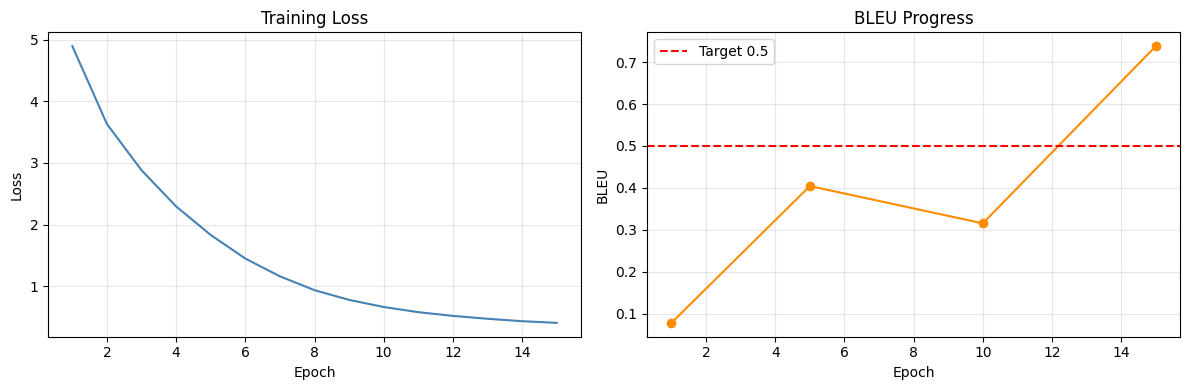

In [16]:
# Training curves
fig,(a1,a2)=plt.subplots(1,2,figsize=(12,4))
a1.plot(range(1,len(losses)+1),losses,color='steelblue')
a1.set(xlabel='Epoch',ylabel='Loss',title='Training Loss'); a1.grid(alpha=0.3)
if bleus:
    ep,sc=zip(*bleus)
    a2.plot(ep,sc,marker='o',color='darkorange')
    a2.axhline(BLEU_TARGET,ls='--',color='red',label=f'Target {BLEU_TARGET}')
    a2.legend()
a2.set(xlabel='Epoch',ylabel='BLEU',title='BLEU Progress'); a2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('b22bb009_training_curve.png',dpi=120,bbox_inches='tight'); plt.show()

In [17]:
torch.save(fm.state_dict(),'b22bb009_ass_4_best_model.pth')
with open('en_vocab.pkl','wb') as f: pickle.dump(en_vocab,f)
with open('hi_vocab.pkl','wb') as f: pickle.dump(hi_vocab,f)
print('Saved: b22bb009_ass_4_best_model.pth')
print('Saved: en_vocab.pkl, hi_vocab.pkl')

Saved: b22bb009_ass_4_best_model.pth
Saved: en_vocab.pkl, hi_vocab.pkl
